<a href="https://colab.research.google.com/github/veenanayak944-bot/Project-based-on-LLM-Transformer/blob/main/GAN_Handwritten_Digit_Generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

print("Dataset shape:", x_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset shape: (60000, 28, 28)


In [3]:
x_train = x_train.astype("float32")

x_train = (x_train - 127.5) / 127.5

x_train = np.expand_dims(x_train, axis=-1)

print(x_train.shape)

(60000, 28, 28, 1)


In [4]:
BATCH_SIZE = 128

dataset = tf.data.Dataset.from_tensor_slices(x_train)

dataset = dataset.shuffle(60000).batch(BATCH_SIZE)

In [5]:
generator = tf.keras.Sequential([

    layers.Dense(7 * 7 * 128, input_shape=(100,)),
    layers.BatchNormalization(),
    layers.LeakyReLU(),

    layers.Reshape((7, 7, 128)),

    layers.Conv2DTranspose(
        64, 5, strides=2, padding="same"
    ),
    layers.BatchNormalization(),
    layers.LeakyReLU(),

    layers.Conv2DTranspose(
        1, 5, strides=2, padding="same",
        activation="tanh"
    )
])

generator.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6272)           │       633,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 6272)           │        25,088 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │       204,864 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 1)      │         1,601 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 865,281 (3.30 MB)

 Trainable params: 852,609 (3.25 MB)

 Non-trainable params: 12,672 (49.50 KB)

In [6]:
discriminator = tf.keras.Sequential([

    layers.Conv2D(
        64, 5, strides=2, padding="same",
        input_shape=(28, 28, 1)
    ),
    layers.LeakyReLU(),
    layers.Dropout(0.3),

    layers.Conv2D(
        128, 5, strides=2, padding="same"
    ),
    layers.LeakyReLU(),
    layers.Dropout(0.3),

    layers.Flatten(),

    layers.Dense(1)
])

discriminator.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(
    from_logits=True
)

def generator_loss(fake_output):
    return cross_entropy(
        tf.ones_like(fake_output),
        fake_output
    )

def discriminator_loss(real_output, fake_output):

    real_loss = cross_entropy(
        tf.ones_like(real_output),
        real_output
    )

    fake_loss = cross_entropy(
        tf.zeros_like(fake_output),
        fake_output
    )

    return real_loss + fake_loss

In [8]:
generator_optimizer = tf.keras.optimizers.Adam(0.0002)

discriminator_optimizer = tf.keras.optimizers.Adam(0.0002)

In [9]:
NOISE_DIM = 100

@tf.function
def train_step(images):

    noise = tf.random.normal(
        [BATCH_SIZE, NOISE_DIM]
    )

    with tf.GradientTape() as gen_tape, \
         tf.GradientTape() as disc_tape:

        generated_images = generator(
            noise,
            training=True
        )

        real_output = discriminator(
            images,
            training=True
        )

        fake_output = discriminator(
            generated_images,
            training=True
        )

        gen_loss = generator_loss(fake_output)

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    gen_gradients = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    disc_gradients = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(
            gen_gradients,
            generator.trainable_variables
        )
    )

    discriminator_optimizer.apply_gradients(
        zip(
            disc_gradients,
            discriminator.trainable_variables
        )
    )

    return gen_loss, disc_loss

In [11]:
EPOCHS = 5

for epoch in range(EPOCHS):

    for image_batch in dataset:

        gen_loss, disc_loss = train_step(
            image_batch
        )

    print(
        "Epoch:",
        epoch + 1,
        "Generator Loss:",
        float(gen_loss),
        "Discriminator Loss:",
        float(disc_loss)
    )

Epoch: 1 Generator Loss: 1.631452202796936 Discriminator Loss: 0.9385603666305542
Epoch: 2 Generator Loss: 1.5687594413757324 Discriminator Loss: 0.7774317264556885
Epoch: 3 Generator Loss: 1.7235472202301025 Discriminator Loss: 0.8122378587722778
Epoch: 4 Generator Loss: 2.1698989868164062 Discriminator Loss: 0.7214401960372925
Epoch: 5 Generator Loss: 1.4106193780899048 Discriminator Loss: 0.9681034088134766


In [12]:
noise = tf.random.normal([16, 100])

generated_images = generator(
    noise,
    training=False
)

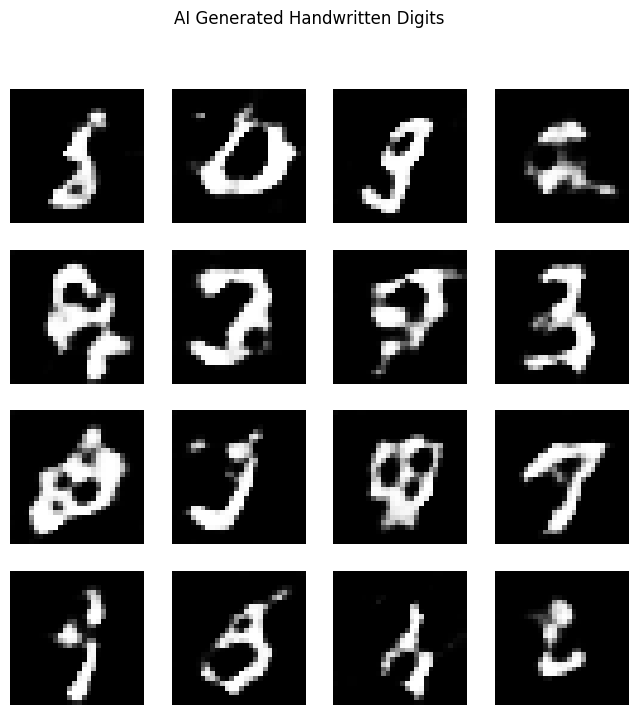

In [13]:
plt.figure(figsize=(8, 8))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    image = (generated_images[i] + 1) / 2

    plt.imshow(
        image[:, :, 0],
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle("AI Generated Handwritten Digits")

plt.show()

In [14]:
import os

os.makedirs("generated_digits", exist_ok=True)

for i in range(16):

    image = (generated_images[i] + 1) / 2

    image = image.numpy()

    plt.imsave(
        f"generated_digits/digit_{i+1}.png",
        image[:, :, 0],
        cmap="gray"
    )

print("Images saved successfully!")

Images saved successfully!


In [15]:
!zip -r generated_digits.zip generated_digits

  adding: generated_digits/ (stored 0%)
  adding: generated_digits/digit_3.png (stored 0%)
  adding: generated_digits/digit_14.png (stored 0%)
  adding: generated_digits/digit_11.png (stored 0%)
  adding: generated_digits/digit_13.png (stored 0%)
  adding: generated_digits/digit_1.png (stored 0%)
  adding: generated_digits/digit_15.png (stored 0%)
  adding: generated_digits/digit_16.png (stored 0%)
  adding: generated_digits/digit_2.png (stored 0%)
  adding: generated_digits/digit_12.png (stored 0%)
  adding: generated_digits/digit_6.png (stored 0%)
  adding: generated_digits/digit_4.png (stored 0%)
  adding: generated_digits/digit_7.png (stored 0%)
  adding: generated_digits/digit_5.png (stored 0%)
  adding: generated_digits/digit_10.png (stored 0%)
  adding: generated_digits/digit_9.png (stored 0%)
  adding: generated_digits/digit_8.png (stored 0%)
